# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hafiz-Taha-Hussain/Flyrank-Work/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup — rebuild the final feature set, label, model, and queue

One consolidated pipeline pulling together w03 (data contract), w05 (model), w06
(validation), and w07 (playbook) into the single source of truth this notebook — and the
paper — both draw their numbers from.

In [1]:
!pip install -q duckdb huggingface_hub scikit-learn matplotlib

import json
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import login

from google.colab import userdata
HF_TOKEN = userdata.get("HF-TOKEN")  # match whatever you actually named the Colab secret
login(token=HF_TOKEN)

REPO_ID = "FlyRank/internship-warehouse"
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""CREATE OR REPLACE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}');""")

MARCH_GLOB = f"hf://datasets/{REPO_ID}/**/month=2026-03/*.parquet"
APRIL_GLOB = f"hf://datasets/{REPO_ID}/**/month=2026-04/*.parquet"

features = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_sum_position) * 1.0 / NULLIF(SUM(gsc_impressions), 0)  AS avg_position_march,
    SUM(gsc_impressions)                                            AS impressions_march,
    SUM(gsc_clicks)                                                 AS clicks_march,
    SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0)         AS ctr_march,
    SUM(ga4_sessions)                                               AS ga4_sessions_march,
    SUM(CASE WHEN ga4_data_available IS TRUE
             THEN ga4_engaged_sessions ELSE 0 END)                  AS engaged_sessions_march,
    SUM(CASE WHEN ga4_data_available IS TRUE
             THEN scroll_events ELSE 0 END)                         AS scroll_events_march,
    SUM(CASE WHEN ga4_data_available IS TRUE
             THEN sessions_ai ELSE 0 END)                           AS ai_sessions_march,
    MAX(CASE WHEN ga4_data_available IS TRUE THEN 1 ELSE 0 END)     AS has_ga4_data
FROM '{MARCH_GLOB}'
GROUP BY client_hash_id, content_hash_id
""").df()

def position_tier(pos):
    if pd.isna(pos): return "no_data"
    elif pos <= 3: return "1-3"
    elif pos <= 10: return "4-10"
    elif pos <= 20: return "11-20"
    elif pos <= 50: return "21-50"
    else: return "51+"

features["position_tier"] = features["avg_position_march"].apply(position_tier)

label = con.sql(f"""
SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS clicks_april
FROM '{APRIL_GLOB}' GROUP BY client_hash_id, content_hash_id
""").df()

data = features.merge(label, on=["client_hash_id", "content_hash_id"], how="inner")
data["declined_in_april"] = (data["clicks_april"] < data["clicks_march"]).astype(int)

feature_cols = [
    "avg_position_march", "impressions_march", "clicks_march", "ctr_march",
    "ga4_sessions_march", "engaged_sessions_march", "scroll_events_march",
    "ai_sessions_march", "has_ga4_data",
]
X = data[feature_cols].fillna(0)
y = data["declined_in_april"]
groups = data["client_hash_id"]

print(f"rows: {len(data)}, clients: {data['client_hash_id'].nunique()}")
print(f"no-visibility rows: {(data['position_tier']=='no_data').sum()} "
      f"({(data['position_tier']=='no_data').mean()*100:.1f}%)")
print(f"base rate (declined_in_april): {y.mean():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows: 331436, clients: 55
no-visibility rows: 154699 (46.7%)
base rate (declined_in_april): 0.136


## 1. Question

*The research question and the decision it supports.*

Given a content page's last-90-day search and engagement signals, which pages should a
content/SEO reviewer look at first this week, and what should they consider doing — refresh,
support, or monitor? The decision this supports: a reviewer with limited weekly capacity
needs a ranked, reasoned starting point instead of manually scanning thousands of pages. A
missed decline (a real, high-demand page that keeps losing visibility unaddressed) costs
more than a wasted review of a stable page — so the project favors not missing genuine
opportunities over raw accuracy.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

- **Release:** FlyRank ML Internship warehouse, `fact_content_daily_performance`
  (Hugging Face, gated), page-day grain.
- **Feature window:** `month=2026-03` (a mid-panel month). **Label window:** `month=2026-04`
  — strictly after the feature window, never overlapping.
- **Excluded:** `fact_content_daily_performance_sample` for any label-building (it is
  exactly June 2026, the natural sealed test month for any past→future label, per the
  warehouse's own panel warning); `trend_direction`/`trend_pct`-style pre-computed columns
  (rule-derived, not observed); GA4 columns on rows where `ga4_data_available` is not `TRUE`
  (zero-filled placeholders, not real zeros).
- **Public-safe:** only pseudonymized `client_hash_id` / `content_hash_id` and aggregate
  counts appear anywhere in this work — no client names, URLs, or raw queries.

In [2]:
print(f"Rows analyzed (one row = one page's March aggregate): {len(data):,}")
print(f"Distinct clients represented: {data['client_hash_id'].nunique()}")
print(f"Rows with no March search visibility (excluded from the action queue): "
      f"{(data['position_tier']=='no_data').sum():,} "
      f"({(data['position_tier']=='no_data').mean()*100:.1f}%)")

Rows analyzed (one row = one page's March aggregate): 331,436
Distinct clients represented: 55
Rows with no March search visibility (excluded from the action queue): 154,699 (46.7%)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

- **Label:** `declined_in_april` = `clicks_april < clicks_march` — a proxy for "this page
  lost ground," built strictly from a later window than every feature.
- **Features (9):** March-only aggregates — position (impression-weighted), impressions,
  clicks, CTR, GA4 sessions, engaged sessions, scroll events, AI-referral sessions, and a
  GA4-availability flag. No feature is derived from April, and none repeats a
  product/decision flag from an existing system.
- **Baseline:** a transparent rule (w04) — score = expected clicks (from a train-only
  position-tier CTR baseline) minus actual clicks, for pages with real demand
  (≥100 impressions/month).
- **Model:** Logistic Regression, then Random Forest (300 trees, depth 8) — chosen because
  this is a ranking ("which ones first?") question, evaluated at precision@50, and because
  the baseline's own top-20 review (w04) showed several signals interacting in ways a single
  linear rule couldn't capture.
- **Validation design:** grouped by `client_hash_id` (GroupShuffleSplit / GroupKFold) — never
  a plain random row split, since content items from the same client share systematic
  factors a random split would let leak between train and test.
- **Leakage checks (w03, w06):** a deliberately planted label-derived feature was shown to
  push AUC to a suspicious 1.000; removing it recovered the honest number. The final feature
  set was checked programmatically for label-derived/sibling columns (none found), window
  overlap (none — March features, April label only), and product-flag inputs (none used).

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

K = 50
RF_PARAMS = dict(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
data_train, data_test = data.iloc[train_idx], data.iloc[test_idx]

# Leakage check, run against the FINAL feature set
forbidden_terms = ["april", "declined", "label", "flag_", "is_declining"]
leaked = [c for c in feature_cols if any(t in c.lower() for t in forbidden_terms)]
assert leaked == [], "Leakage detected in final feature set."
print("Leakage check on final feature set: clean —", feature_cols)

train_demand = data_train[data_train["impressions_march"] >= 100]
tier_baseline_ctr = train_demand.groupby("position_tier")["ctr_march"].mean()
test_baseline = data_test.copy()
test_baseline["tier_baseline_ctr"] = test_baseline["position_tier"].map(tier_baseline_ctr)
test_baseline["expected_clicks"] = test_baseline["impressions_march"] * test_baseline["tier_baseline_ctr"]
test_baseline["missed_clicks"] = (test_baseline["expected_clicks"] - test_baseline["clicks_march"]).clip(lower=0)
has_demand_test = test_baseline["impressions_march"] >= 100
baseline_score = np.where(has_demand_test, test_baseline["missed_clicks"].fillna(0), 0.0)
baseline_p50 = precision_at_k(baseline_score, y_test.values, K)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
logreg_p50 = precision_at_k(logreg.predict_proba(X_test)[:, 1], y_test.values, K)

rf = RandomForestClassifier(**RF_PARAMS)
rf.fit(X_train, y_train)
rf_p50 = precision_at_k(rf.predict_proba(X_test)[:, 1], y_test.values, K)

base_rate = y_test.mean()
print(f"base rate: {base_rate:.3f} | baseline: {baseline_p50:.3f} | "
      f"logreg: {logreg_p50:.3f} | random forest: {rf_p50:.3f}")

Leakage check on final feature set: clean — ['avg_position_march', 'impressions_march', 'clicks_march', 'ctr_march', 'ga4_sessions_march', 'engaged_sessions_march', 'scroll_events_march', 'ai_sessions_march', 'has_ga4_data']
base rate: 0.134 | baseline: 0.520 | logreg: 0.800 | random forest: 0.940


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

                              method  precision_at_50
                           Base rate         0.134034
                   w04 rule baseline         0.520000
                 Logistic Regression         0.800000
Random Forest (single grouped split)         0.940000
 Random Forest (5-fold grouped mean)         0.952000

5-fold spread: 0.041 (range 0.90-1.00)


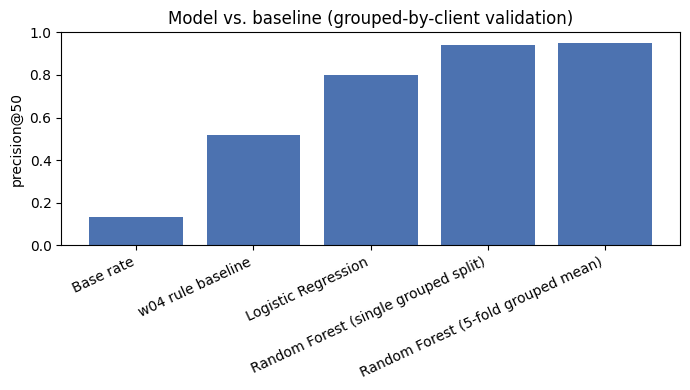

In [4]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
fold_scores = []
for tr_idx, te_idx in gkf.split(X, y, groups=groups):
    rf_fold = RandomForestClassifier(**RF_PARAMS)
    rf_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred = rf_fold.predict_proba(X.iloc[te_idx])[:, 1]
    fold_scores.append(precision_at_k(pred, y.iloc[te_idx].values, K))

results = pd.DataFrame({
    "method": ["Base rate", "w04 rule baseline", "Logistic Regression",
               "Random Forest (single grouped split)", "Random Forest (5-fold grouped mean)"],
    "precision_at_50": [base_rate, baseline_p50, logreg_p50, rf_p50, np.mean(fold_scores)],
})
print(results.to_string(index=False))
print(f"\n5-fold spread: {np.std(fold_scores):.3f} (range {min(fold_scores):.2f}-{max(fold_scores):.2f})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results["method"], results["precision_at_50"], color="#4C72B0")
ax.set_ylabel("precision@50"); ax.set_ylim(0, 1)
ax.set_title("Model vs. baseline (grouped-by-client validation)")
plt.xticks(rotation=25, ha="right"); plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/model_comparison.png", dpi=150)
plt.show()

## 5. Limitations

*What this work cannot claim.*

- **Single month-pair.** Trained and validated on March→April 2026 only; not yet tested on
  other months, seasons, or a materially different client mix. The 5-fold grouped CV spread
  (std ≈0.05, fold range 0.86-1.00) shows real variability even within this one window.
- **Proxy label.** `declined_in_april` is a click-count comparison, not a confirmed cause of
  decline — it can reflect seasonality, an algorithm update, or a whole client's portfolio
  moving together, not necessarily a fixable content problem (see the false-positive
  analysis below).
- **Coverage gap.** ~46.7% of March rows have no search visibility at all and are excluded
  from the action queue entirely — this work says nothing about undiscovered or unindexed
  content.
- **No causal claim.** Every result here is observational; this work never claims that
  acting on a flagged page will cause its metrics to recover.
- **Known data-quality artifact.** Several top-ranked baseline flags had an average position
  under 1.0, which is implausible for a genuine organic ranking and likely reflects a
  SERP-feature (image pack, video carousel) rather than a real anomaly — a human check is
  required before trusting any such flag.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Every page gets an out-of-fold model score (no row scored by a model trained on it), then a
reason code and action from a small, interpretable rule set.

In [5]:
from sklearn.model_selection import cross_val_predict

rf_for_scoring = RandomForestClassifier(**RF_PARAMS)
oof_proba = cross_val_predict(rf_for_scoring, X, y, cv=gkf, groups=groups,
                               method="predict_proba", n_jobs=-1)[:, 1]
data["model_score"] = oof_proba

def assign_reason_and_action(row, threshold):
    if row["position_tier"] == "no_data":
        return "no_search_visibility", "not_applicable"
    if row["model_score"] < threshold:
        return "healthy", "no_action"
    if row["impressions_march"] < 100:
        return "low_demand_flagged", "monitor_only"
    if row["position_tier"] in ("1-3", "4-10"):
        return "page_one_at_risk", "protect_and_refresh"
    elif row["position_tier"] == "11-20":
        return "striking_distance_opportunity", "support_striking_distance"
    else:
        return "visible_but_declining", "review_for_refresh"

scoreable = data[(data["position_tier"] != "no_data") & (data["impressions_march"] >= 100)]
score_threshold = scoreable["model_score"].quantile(0.80)

reason_action = data.apply(lambda r: assign_reason_and_action(r, score_threshold), axis=1)
data["reason_code"] = [r[0] for r in reason_action]
data["action"] = [r[1] for r in reason_action]

queue = data.sort_values("model_score", ascending=False).reset_index(drop=True)
print(queue["reason_code"].value_counts())
print()
actionable = queue[queue["action"].isin(
    ["protect_and_refresh", "review_for_refresh", "support_striking_distance"]
)]
print(f"Actionable queue size: {len(actionable):,} pages "
      f"(+ {(queue['action']=='monitor_only').sum():,} monitor-only)")

reason_code
no_search_visibility             154699
healthy                          151443
page_one_at_risk                   8875
visible_but_declining              5868
striking_distance_opportunity      5546
low_demand_flagged                 5005
Name: count, dtype: int64

Actionable queue size: 20,289 pages (+ 5,005 monitor-only)


**Recommendations, ranked by expected reviewer value:**

1. **Protect and refresh page-one-at-risk pages first** (`page_one_at_risk`) — these already
   hold visibility that took work to earn; losing it is the most expensive failure mode.
2. **Support striking-distance pages** (`striking_distance_opportunity`, positions 11-20) —
   the highest-ROI zone, since a small position gain here can produce an outsized click gain.
3. **Review visible-but-declining pages** (`visible_but_declining`) for a standard refresh.
4. **Monitor low-demand flagged pages** (`low_demand_flagged`) rather than actively reviewing
   them — the false-positive analysis (w05) showed these are the most volatile, since a
   single click can swing their ratio.
5. **Leave the no-visibility segment (46.7% of pages) out of this workflow** — it needs an
   indexing/discovery fix, not a content-review queue.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [6]:
os.makedirs("../outputs", exist_ok=True)

metrics = {
    "task": "Lane 2 — Refresh/Content Opportunity Scoring",
    "rows_analyzed": int(len(data)),
    "clients": int(data["client_hash_id"].nunique()),
    "no_visibility_share": float((data["position_tier"] == "no_data").mean()),
    "precision_at_50": {
        "base_rate": float(base_rate),
        "w04_rule_baseline": float(baseline_p50),
        "logistic_regression": float(logreg_p50),
        "random_forest_single_split": float(rf_p50),
        "random_forest_5fold_mean": float(np.mean(fold_scores)),
        "random_forest_5fold_std": float(np.std(fold_scores)),
    },
    "queue": {
        "actionable_pages": int(len(actionable)),
        "monitor_only_pages": int((queue["action"] == "monitor_only").sum()),
        "reason_code_counts": queue["reason_code"].value_counts().to_dict(),
    },
}
with open("../outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Artifacts ready for the paper:")
print("  ../figures/model_comparison.png  (chart, section 4)")
print("  ../outputs/capstone_metrics.json (numbers, all sections — commit this one)")
print()
print(json.dumps(metrics, indent=2))

Artifacts ready for the paper:
  ../figures/model_comparison.png  (chart, section 4)
  ../outputs/capstone_metrics.json (numbers, all sections — commit this one)

{
  "task": "Lane 2 \u2014 Refresh/Content Opportunity Scoring",
  "rows_analyzed": 331436,
  "clients": 55,
  "no_visibility_share": 0.46675376241567,
  "precision_at_50": {
    "base_rate": 0.13403448206651547,
    "w04_rule_baseline": 0.52,
    "logistic_regression": 0.8,
    "random_forest_single_split": 0.94,
    "random_forest_5fold_mean": 0.952,
    "random_forest_5fold_std": 0.04118252056394799
  },
  "queue": {
    "actionable_pages": 20289,
    "monitor_only_pages": 5005,
    "reason_code_counts": {
      "no_search_visibility": 154699,
      "healthy": 151443,
      "page_one_at_risk": 8875,
      "visible_but_declining": 5868,
      "striking_distance_opportunity": 5546,
      "low_demand_flagged": 5005
    }
  }
}


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.